In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# import h5py
import glob

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "scripts"))

import plotting_utils as pu
import directories as dirs

results:   0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
dtau_paths = glob.glob('/mnt/home/nkhusid/ceph/spec_inj/DS/220/220+221_DS_GW250114Kerr*fmin10Hz_ppSNR20_dfpre-0.5*')

In [4]:
np.sort(dtau_paths)

array(['/mnt/home/nkhusid/ceph/spec_inj/DS/220/220+221_DS_GW250114Kerr_dtaupre0_fmin10Hz_ppSNR20_dfpre-0.5',
       '/mnt/home/nkhusid/ceph/spec_inj/DS/220/220+221_DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-0.5_dtaupre-0.5',
       '/mnt/home/nkhusid/ceph/spec_inj/DS/220/220+221_DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-0.5_dtaupre-0.75',
       '/mnt/home/nkhusid/ceph/spec_inj/DS/220/220+221_DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-0.5_dtaupre-1.5',
       '/mnt/home/nkhusid/ceph/spec_inj/DS/220/220+221_DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-0.5_dtaupre-3.0'],
      dtype='<U102')

In [5]:
colls = {f"-{path.split('-')[-1]}" if 'df' not in path.split('-')[-2] else '0': rd.ResultCollection.from_netcdf(f'{path}/engine/*/result.nc') for path in np.sort(dtau_paths)}

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/11 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [6]:
colls

{'0': ResultCollection([(1126259462.418712,), (1126259462.419784,), (1126259462.420856,), (1126259462.421928,), (1126259462.423,), (1126259462.424072,), (1126259462.425144,), (1126259462.426216,), (1126259462.427289,)]),
 '-0.5': ResultCollection([(1126259462.418712,), (1126259462.419784,), (1126259462.420856,), (1126259462.421928,), (1126259462.423,), (1126259462.424072,), (1126259462.425144,), (1126259462.426216,), (1126259462.427289,)]),
 '-0.75': ResultCollection([(1126259462.418712,), (1126259462.419784,), (1126259462.420856,), (1126259462.421928,), (1126259462.423,), (1126259462.424072,), (1126259462.425144,), (1126259462.426216,), (1126259462.427289,)]),
 '-1.5': ResultCollection([(1126259462.416568,), (1126259462.41764,), (1126259462.418712,), (1126259462.419784,), (1126259462.420856,), (1126259462.421928,), (1126259462.423,), (1126259462.424072,), (1126259462.425144,), (1126259462.426216,), (1126259462.427289,)]),
 '-3.0': ResultCollection([(1126259462.418712,), (1126259462.41

In [7]:
for coll in colls.values():
    coll.reindex_by_t0(reference_time=1126259462.423, reference_mass=coll[0].config['model']['m_min'] * 2, decimals=0)

In [8]:
dfs = {k: coll.get_parameter_dataframe(ndraw=500, progress=True, prng=13) for k, coll in colls.items()}

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/11 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

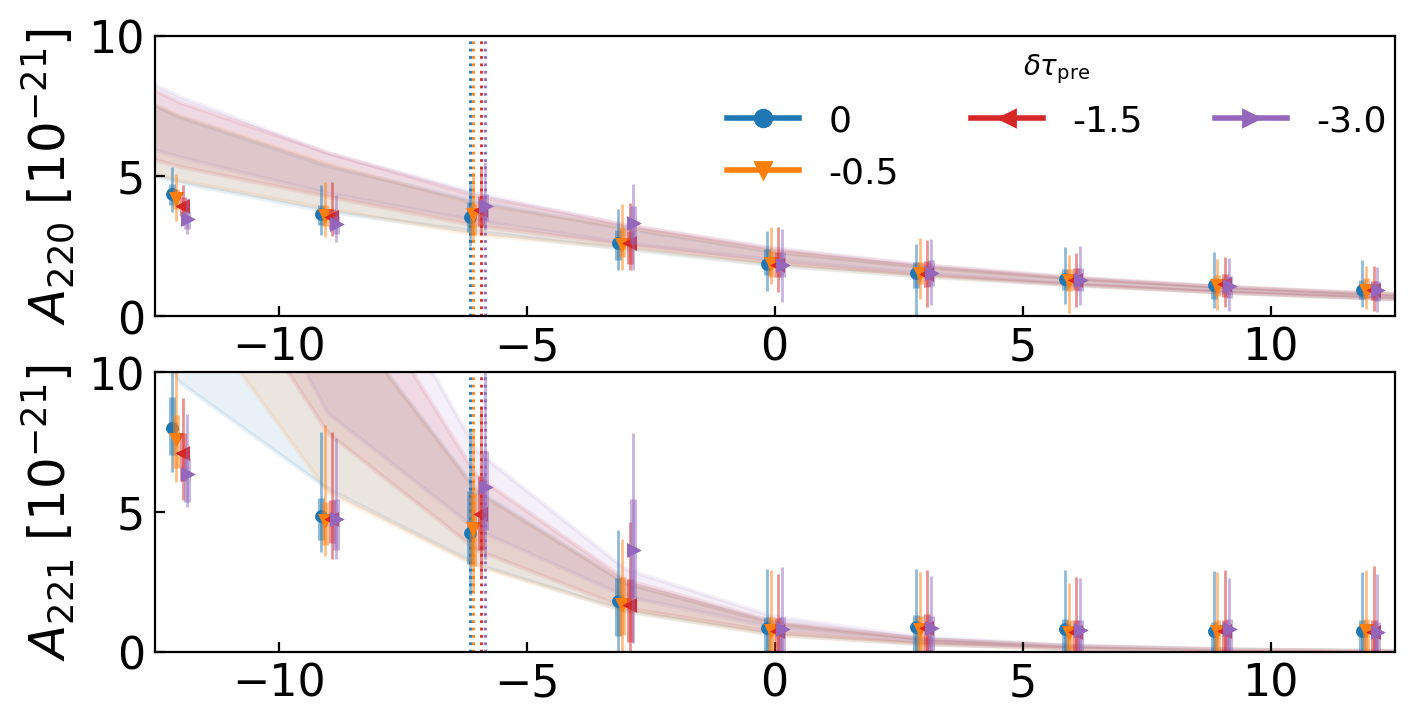

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4))
filled = list(plt.Line2D.filled_markers)

clevs = [0.95, 0.68]

tref = [-6, -6, -6, -6, -6]
legend_handles = []
for mark, (k, df) in enumerate(dfs.items()):
    if k != '-0.75':
        c = f'C{mark}'

        combo = '220+221'
        a_dfs = {combo: {mode: pu.get_projection(df, mode, tref[mark]) for mode in combo.split('+')}}
        for i, mode in enumerate(combo.split('+')):
            # if i < len(modes_true):
            shift = np.linspace(-0.15, 0.15, len(dfs))[mark]
            pu.plot_scan(df, mode, clevs, c, ax[i], marker=filled[mark+1], shift=shift, a_scale=1e-21)
            pu.plot_projection(a_dfs[combo][mode], [min(clevs)], ax[i], color=c, a_scale=1e-21)
            ax[i].axvline(tref[mark]+shift, ls=':', lw=1, color=c)

            ax[i].set_ylabel(f'$A_{{{mode}}}$ [$10^{{{-21}}}$]', fontsize=18)
            ax[i].set_xlim(-12.5, 12.5)
            ax[i].set_ylim(0, 10)
            ax[i].tick_params(axis='both', labelsize=16, direction='in')
        
        legend_handles.append(plt.Line2D([0, 0], [0, 1], color=c, marker=filled[mark+1], 
                                        linestyle='-', linewidth=2, label=k, 
                                        markerfacecolor=c, markeredgecolor=c))

leg = ax[0].legend(handles=legend_handles, loc=(0.45, 0.4), frameon=False, ncol=3, fontsize=13, title='$\delta\\tau_{\mathrm{pre}}$')

In [49]:
f_inj = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/DS/220/DS_GW250114Kerr_dfpre0_dtaupre0_fmin10Hz_ppSNR20_H1.hdf5', key='H1')
fo_inj = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/DS/220+221/DS_GW250114Kerr_dfpre0_dtaupre0_fmin10Hz_ppSNR20_H1.hdf5', key='H1')
ff_inj = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/DS/220+210/DS_GW250114Kerr_dfpre0_dtaupre0_fmin10Hz_ppSNR20_H1.hdf5', key='H1')

In [50]:
ds_inj = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/DS/*/DS_GW250114Kerr_dtaupre0_fmin10Hz_ppSNR20_dfpre0_H1.hdf5')
ds_inj_v = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/DS/*/DS_GW250114Kerr_dtaupre0_fmin10Hz_ppSNR20_dfpre-0.5_H1.hdf5')
ds_inj_d = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/DS/*/DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-0.5_dtaupre-1.5_H1.hdf5')

In [55]:
ds_inj_sd =np.sort(glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/DS/220+221/DS_GW250114Kerr*fmin10Hz_ppSNR20_dfpre*_dtaupre0_H1.hdf5'))

In [56]:
ds_inj_sd

array(['/mnt/home/nkhusid/spec_inj/data/injections/DS/220+221/DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-0.5_dtaupre0_H1.hdf5',
       '/mnt/home/nkhusid/spec_inj/data/injections/DS/220+221/DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-1.0_dtaupre0_H1.hdf5',
       '/mnt/home/nkhusid/spec_inj/data/injections/DS/220+221/DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-1.5_dtaupre0_H1.hdf5',
       '/mnt/home/nkhusid/spec_inj/data/injections/DS/220+221/DS_GW250114Kerr_fmin10Hz_ppSNR20_dfpre-2.0_dtaupre0_H1.hdf5'],
      dtype='<U113')

In [57]:
ds_dfs_sd = {inj.split('_')[-3]+'_'+inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(ds_inj_sd)}

In [ ]:
ds_dfs = {inj.split('/')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(ds_inj)}
ds_dfs_v = {inj.split('/')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(ds_inj_v)}
ds_dfs_d = {inj.split('/')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(ds_inj_d)}

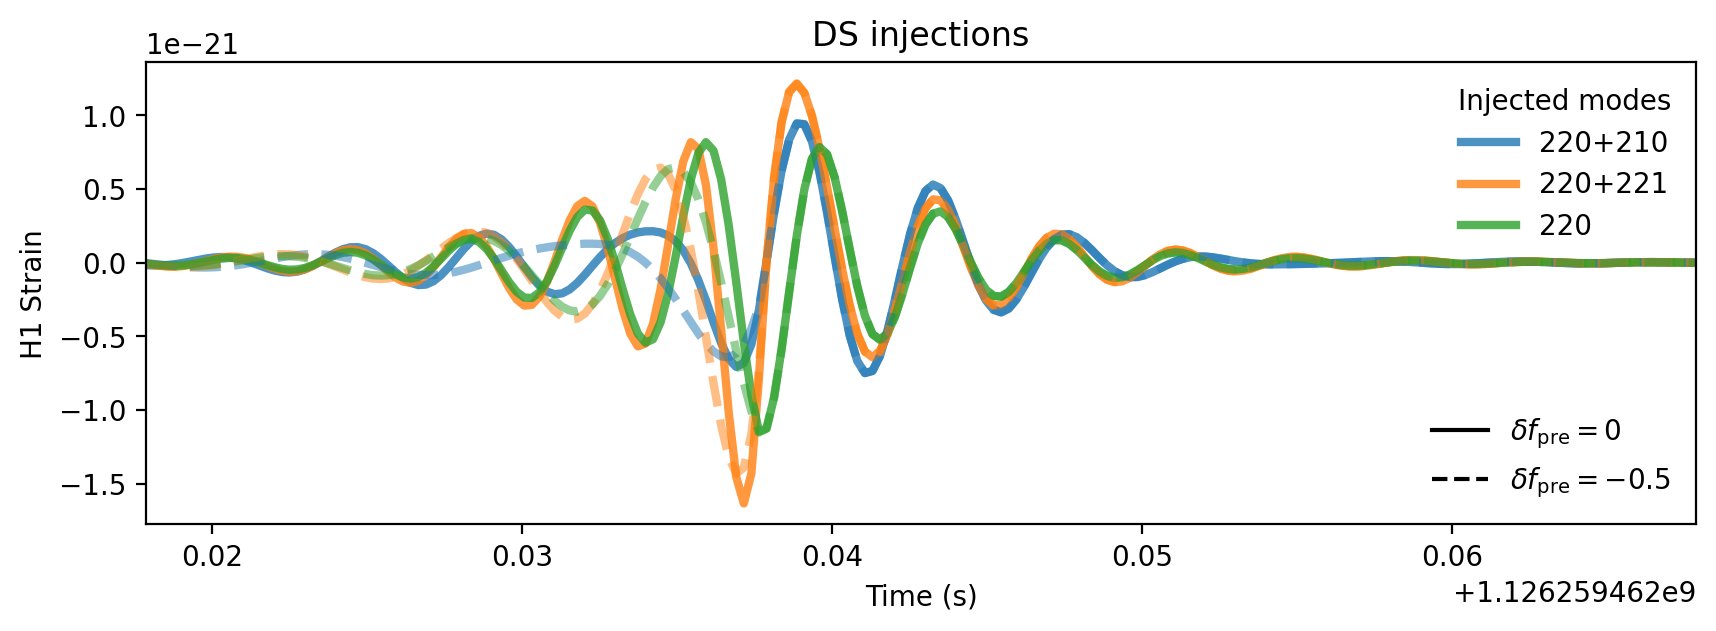

In [52]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (modes, df) in enumerate(ds_dfs.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=modes)
for i, (modes, df) in enumerate(ds_dfs_v.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.5, ls='--')

ax.set_xlim(np.median(df.index.values)-0.005, np.median(df.index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('DS injections')

leg1 = ax.legend(frameon=False, title='Injected modes')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$\delta f_{\mathrm{pre}} = 0$',
                  '$\delta f_{\mathrm{pre}} = -0.5$'], 
                 frameon=False, loc='lower right')

In [10]:
TM = rd.qnms.T_MSUN * 72.55320774907538
start = 1126259462.437694

In [7]:
fit_peak = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined_miness300/engine/1126259462.423000/config.ini')

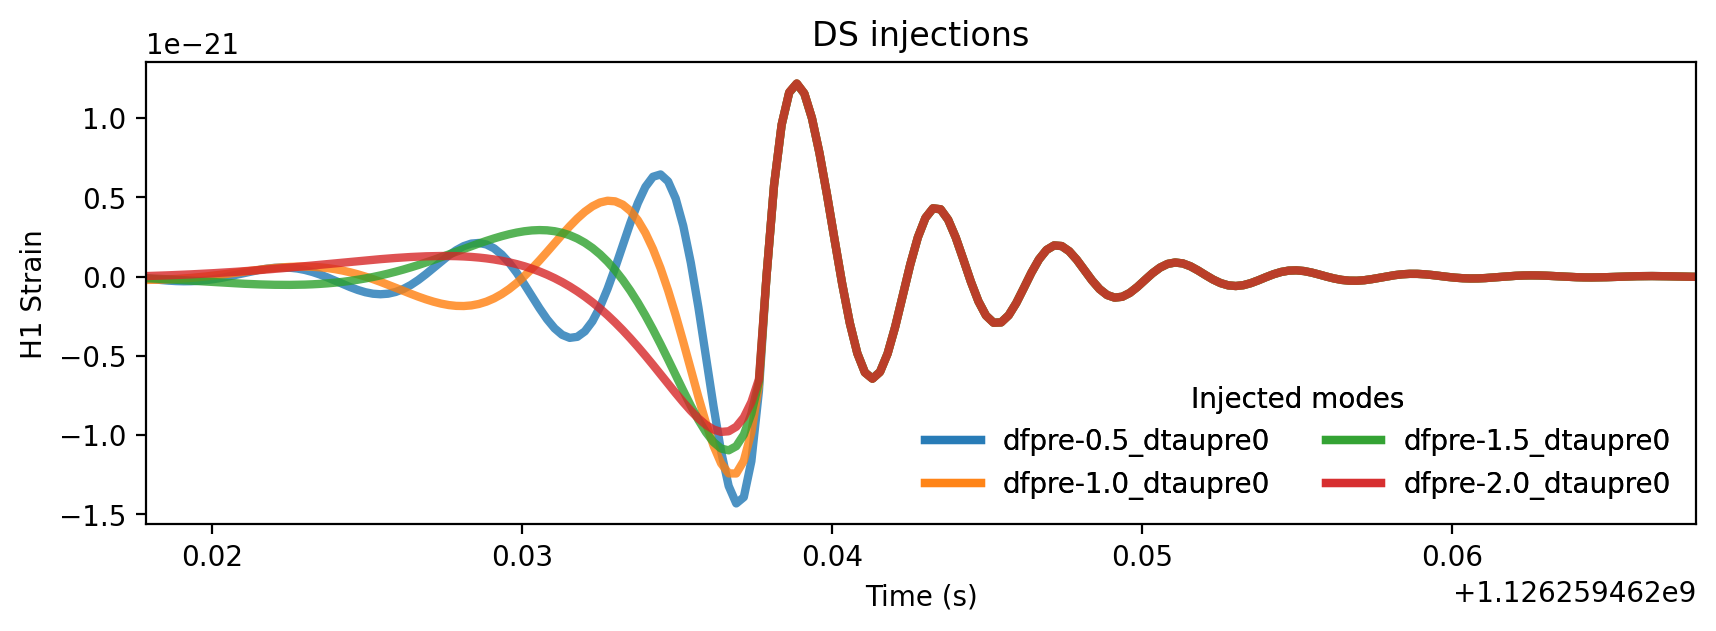

In [58]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (dtau_pre, df) in enumerate(ds_dfs_sd.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=dtau_pre)

ax.set_xlim(np.median(df.index.values)-0.005, np.median(df.index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('DS injections')

leg1 = ax.legend(frameon=False, title='Injected modes', loc='lower right', ncol=2)
ax.add_artist(leg1)

# leg2 = ax.legend([plt.Line2D([], [], color='k'), 
#                   plt.Line2D([], [], color='k', ls='--')], 
#                  ['$\delta f_{\mathrm{pre}} = 0$',
#                   '$\delta f_{\mathrm{pre}} = -0.5$'], 
#                  frameon=False, loc='lower right')

In [60]:
psd = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_H1_psd_patched4kHz_1e-40.hdf5', key='H1')

In [61]:
psd

0.000       1.000000e-40
0.125       1.000000e-40
0.250       1.000000e-40
0.375       1.000000e-40
0.500       1.000000e-40
                ...     
2047.500    1.000000e-40
2047.620    1.000000e-40
2047.750    1.000000e-40
2047.880    1.000000e-40
2048.000    1.000000e-40
Name: H1, Length: 16385, dtype: float64

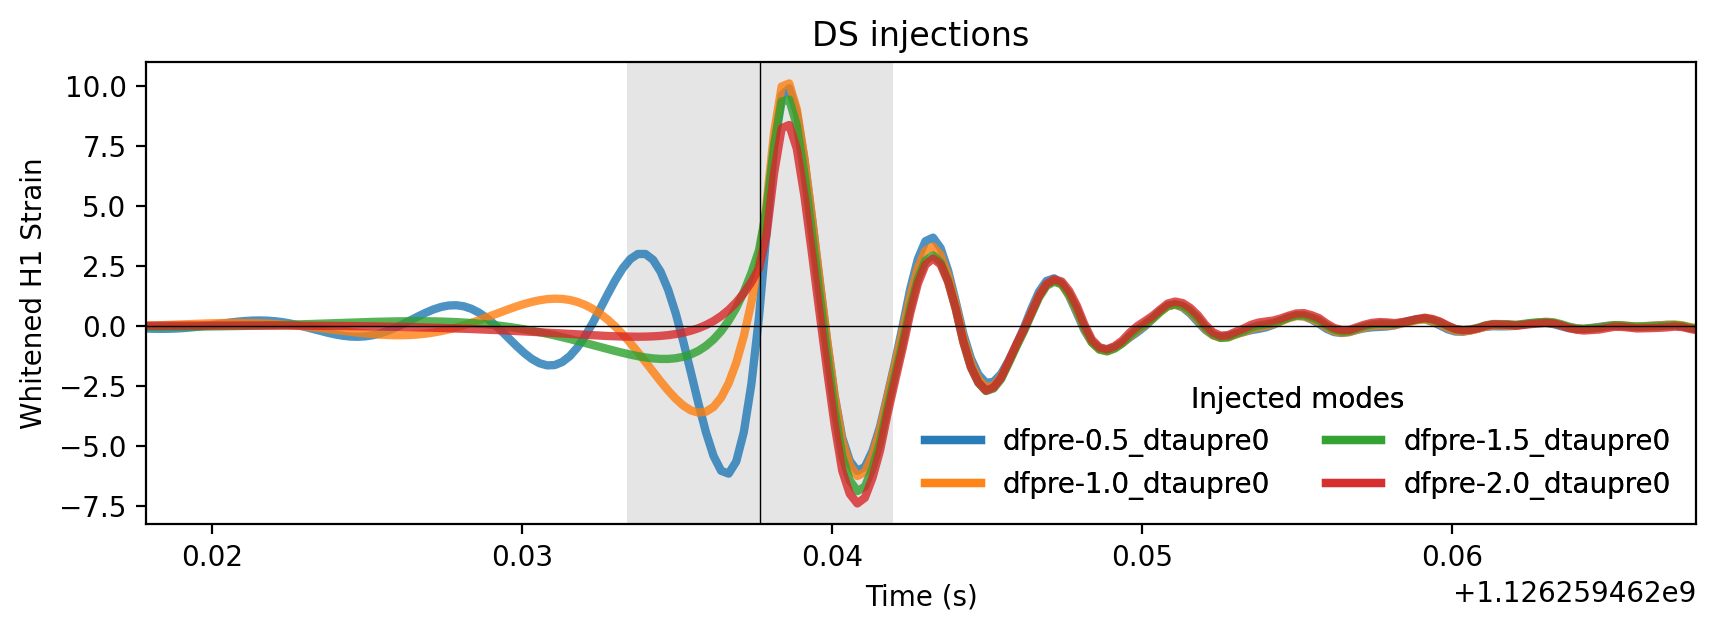

In [59]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (dtau_pre, df) in enumerate(ds_dfs_sd.items()):
    # if i in [4, 6, 7, 8]:
    if i > -1:
        wd = fit_peak.whiten({'H1': df})
        ax.plot(df.index.values, wd['H1'], color=f'C{i}', lw=3, alpha=0.8, label=dtau_pre)

ax.set_xlim(np.median(df.index.values)-0.005, np.median(df.index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Whitened H1 Strain')
ax.set_title('DS injections')

leg1 = ax.legend(frameon=False, title='Injected modes', ncol=2, loc='lower right')
ax.add_artist(leg1)

ax.axvline(start, lw=0.5, c='k')
ax.axhline(0, lw=0.5, c='k')
ax.axvspan(start - 12*TM, start + 12*TM, color='gray', alpha=0.2, lw=0)

# leg2 = ax.legend([plt.Line2D([], [], color='k'), 
#                   plt.Line2D([], [], color='k', ls='--')], 
#                  ['$\delta f_{\mathrm{pre}} = 0$',
#                   '$\delta f_{\mathrm{pre}} = -0.5$'], 
#                  frameon=False, loc='lower right')

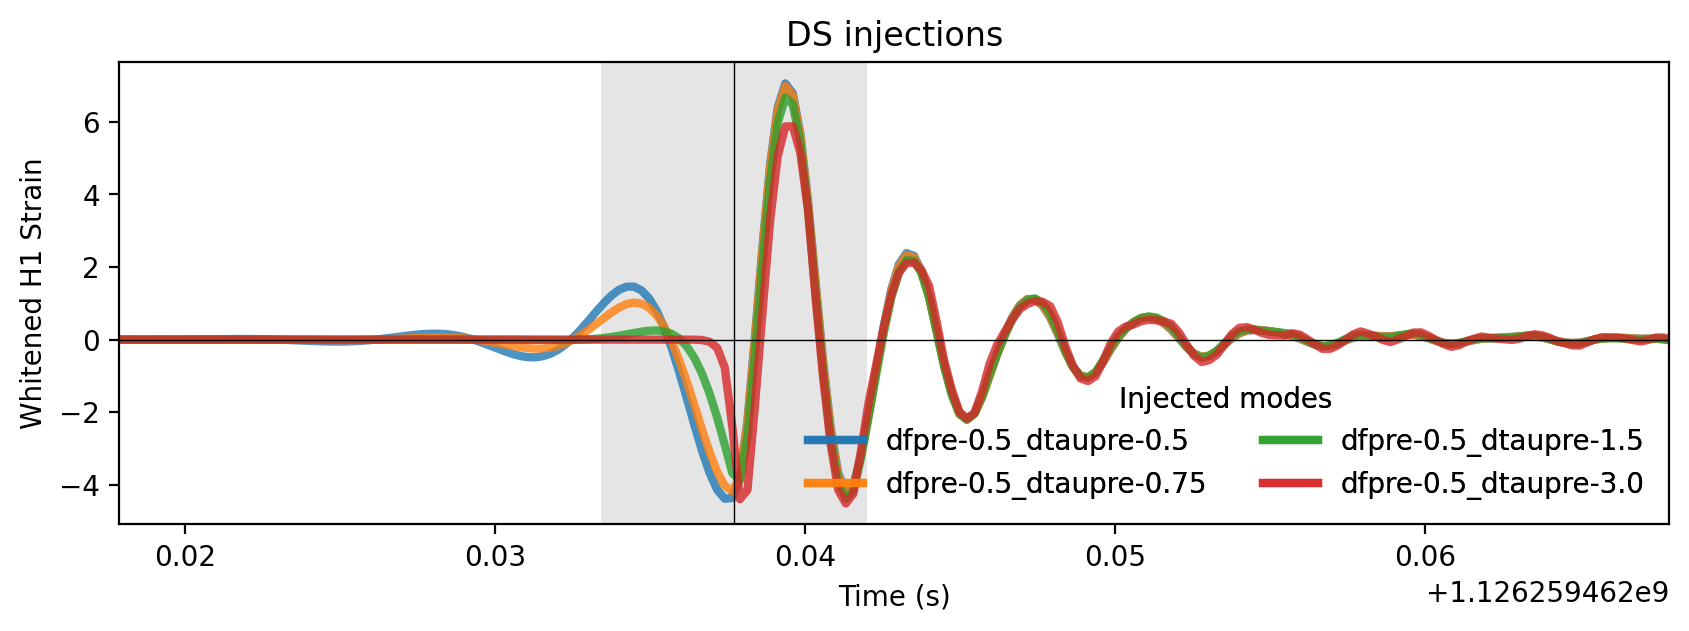

In [59]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (dtau_pre, df) in enumerate(ds_dfs_sd.items()):
    if i in [0, 1, 2, 3]:
        wd = fit_peak.whiten({'H1': df})
        ax.plot(df.index.values, wd['H1'], color=f'C{i}', lw=3, alpha=0.8, label=dtau_pre)

ax.set_xlim(np.median(df.index.values)-0.005, np.median(df.index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Whitened H1 Strain')
ax.set_title('DS injections')

leg1 = ax.legend(frameon=False, title='Injected modes', ncol=2, loc='lower right')
ax.add_artist(leg1)

ax.axvline(start, lw=0.5, c='k')
ax.axhline(0, lw=0.5, c='k')
ax.axvspan(start - 12*TM, start + 12*TM, color='gray', alpha=0.2, lw=0)

# leg2 = ax.legend([plt.Line2D([], [], color='k'), 
#                   plt.Line2D([], [], color='k', ls='--')], 
#                  ['$\delta f_{\mathrm{pre}} = 0$',
#                   '$\delta f_{\mathrm{pre}} = -0.5$'], 
#                  frameon=False, loc='lower right')

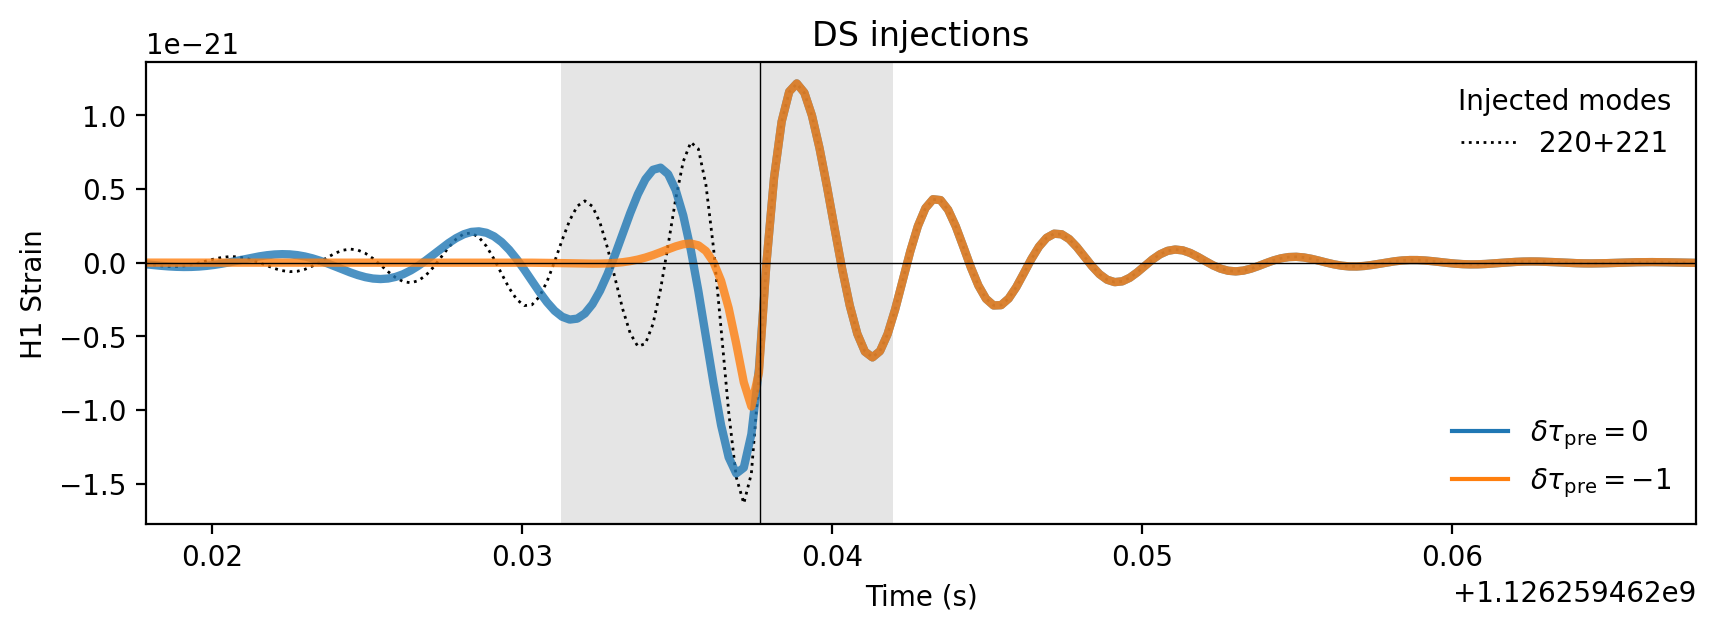

In [60]:
modes = '220+221'
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ds_dfs[modes], color='k', lw=1, alpha=1, ls=':', label=modes)
ax.plot(ds_dfs_v[modes], color='C0', lw=3, alpha=0.8)
ax.plot(ds_dfs_d[modes], color='C1', lw=3, alpha=0.8)

ax.set_xlim(np.median(ds_dfs_d[modes].index.values)-0.005, np.median(ds_dfs_d[modes].index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('DS injections')

ax.axvline(start, lw=0.5, c='k')
ax.axhline(0, lw=0.5, c='k')
ax.axvspan(start - 18*TM, start + 12*TM, color='gray', alpha=0.2, lw=0)

leg1 = ax.legend(frameon=False, title='Injected modes')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='C0'), 
                  plt.Line2D([], [], color='C1')], 
                 ['$\delta \\tau_{\mathrm{pre}} = 0$',
                  '$\delta \\tau_{\mathrm{pre}} = -1$'], 
                 frameon=False, loc='lower right')

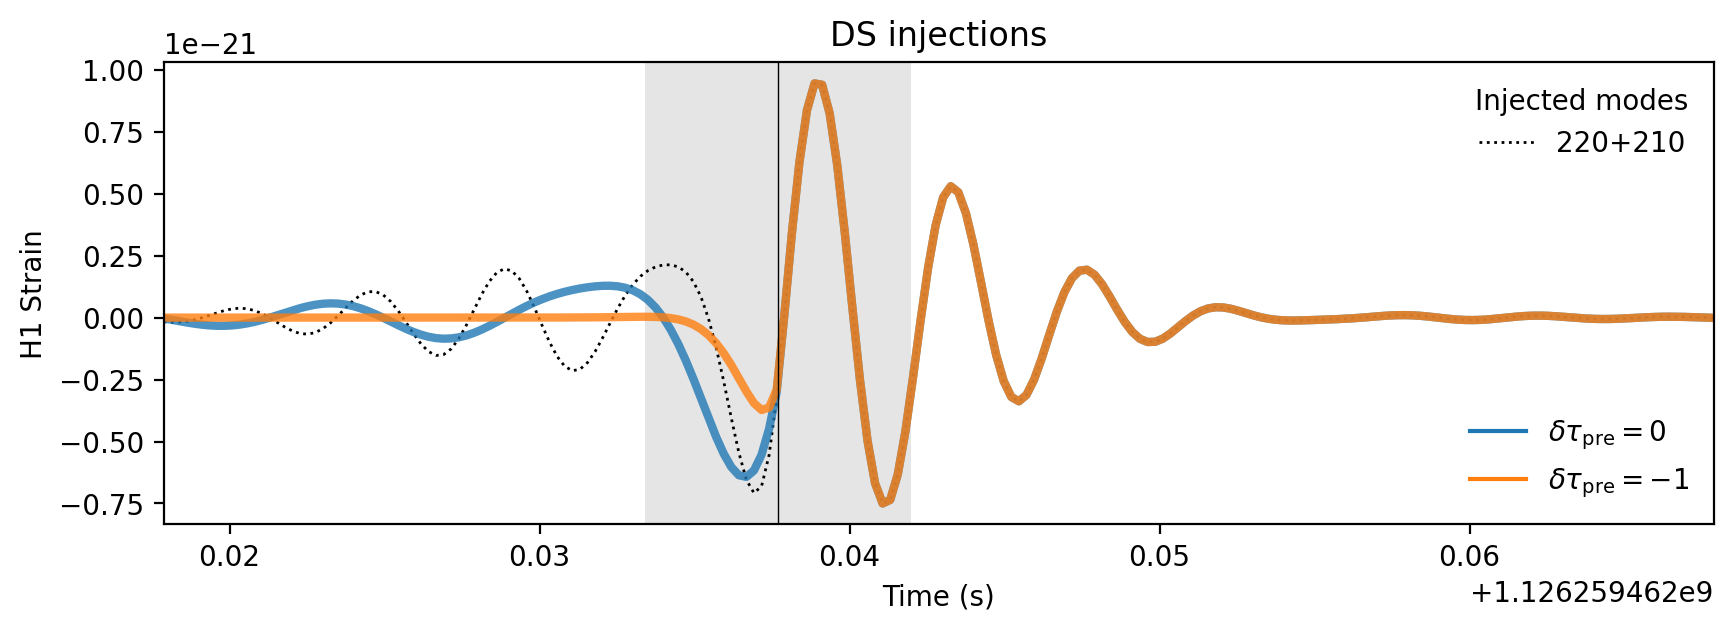

In [54]:
modes = '220+210'
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ds_dfs[modes], color='k', lw=1, alpha=1, ls=':', label=modes)
ax.plot(ds_dfs_v[modes], color='C0', lw=3, alpha=0.8)
ax.plot(ds_dfs_d[modes], color='C1', lw=3, alpha=0.8)

ax.set_xlim(np.median(ds_dfs_d[modes].index.values)-0.005, np.median(ds_dfs_d[modes].index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('DS injections')

ax.axvline(start, lw=0.5, c='k')
ax.axvspan(start - 12*TM, start + 12*TM, color='gray', alpha=0.2, lw=0)

leg1 = ax.legend(frameon=False, title='Injected modes')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='C0'), 
                  plt.Line2D([], [], color='C1')], 
                 ['$\delta \\tau_{\mathrm{pre}} = 0$',
                  '$\delta \\tau_{\mathrm{pre}} = -1$'], 
                 frameon=False, loc='lower right')

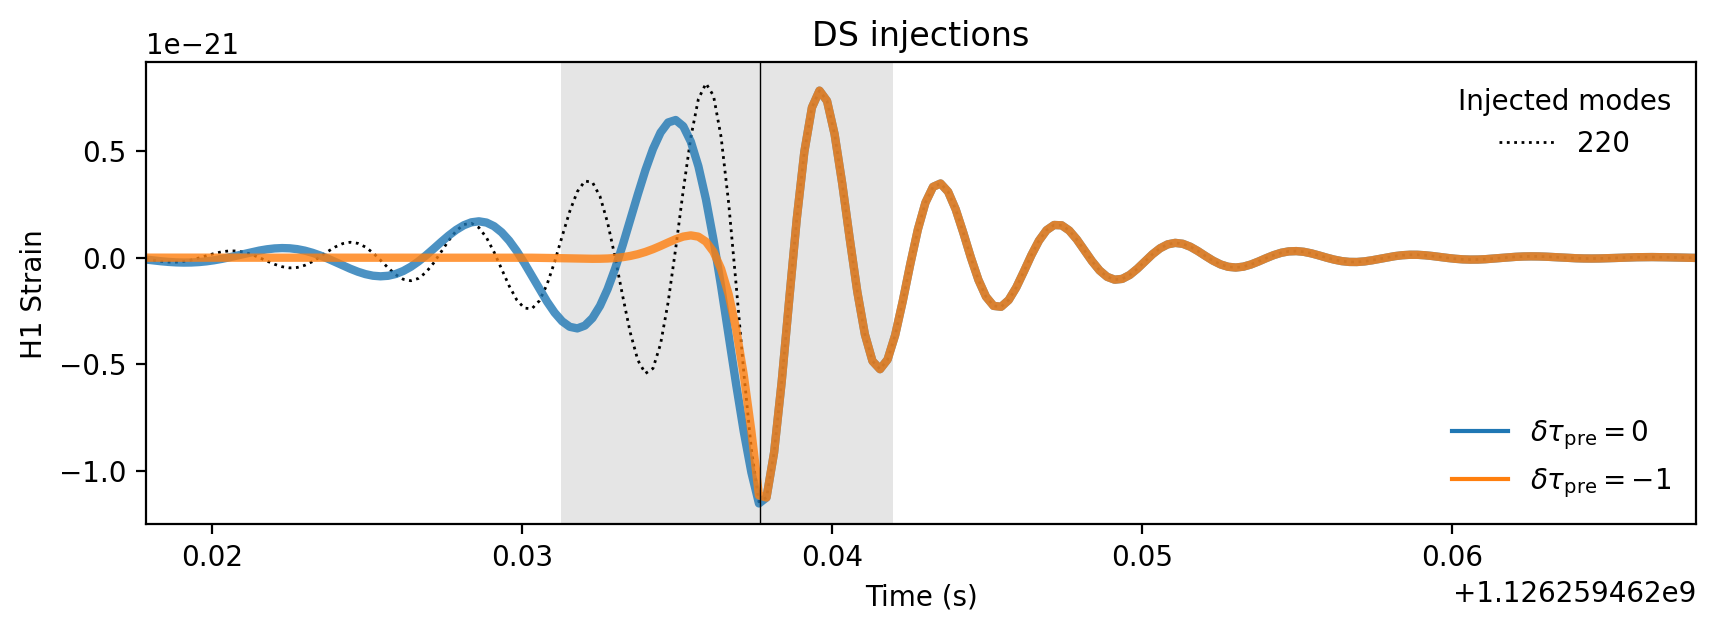

In [56]:
modes = '220'
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ds_dfs[modes], color='k', lw=1, alpha=1, ls=':', label=modes)
ax.plot(ds_dfs_v[modes], color='C0', lw=3, alpha=0.8)
ax.plot(ds_dfs_d[modes], color='C1', lw=3, alpha=0.8)

ax.set_xlim(np.median(ds_dfs_d[modes].index.values)-0.005, np.median(ds_dfs_d[modes].index.values)+0.045)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('DS injections')

ax.axvline(start, lw=0.5, c='k')
ax.axvspan(start - 18*TM, start + 12*TM, color='gray', alpha=0.2, lw=0)

leg1 = ax.legend(frameon=False, title='Injected modes')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='C0'), 
                  plt.Line2D([], [], color='C1')], 
                 ['$\delta \\tau_{\mathrm{pre}} = 0$',
                  '$\delta \\tau_{\mathrm{pre}} = -1$'], 
                 frameon=False, loc='lower right')